In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
df = pd.read_excel("Telco_customer_churn.xlsx")
df.to_csv("data.csv", index=False)

In [3]:
print(df['Total Charges'].head(10))
print(df['Total Charges'].dtype)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object
object


In [4]:
for x in df['Total Charges'].head(10):
    print(repr(x))

108.15
151.65
820.5
3046.05
5036.3
528.35
39.65
20.15
4749.15
30.2


In [5]:
print(df['Total Charges'].apply(type).value_counts())
print(repr(df['Total Charges'].iloc[0]))

Total Charges
<class 'float'>    6708
<class 'int'>       324
<class 'str'>        11
Name: count, dtype: int64
108.15


In [6]:
(df['Total Charges'] == ' ').sum()

11

In [7]:
df['Total Charges'] = df['Total Charges'].replace(' ', np.nan)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18128\1835936537.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total Charges'] = df['Total Charges'].replace(' ', np.nan)


In [8]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'])
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

In [9]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [11]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2281.916928,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.270398,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [12]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [13]:
df.drop('CustomerID', axis=1, inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Zip Code           7043 non-null   int64  
 5   Lat Long           7043 non-null   object 
 6   Latitude           7043 non-null   float64
 7   Longitude          7043 non-null   float64
 8   Gender             7043 non-null   object 
 9   Senior Citizen     7043 non-null   object 
 10  Partner            7043 non-null   object 
 11  Dependents         7043 non-null   object 
 12  Tenure Months      7043 non-null   int64  
 13  Phone Service      7043 non-null   object 
 14  Multiple Lines     7043 non-null   object 
 15  Internet Service   7043 non-null   object 
 16  Online Security    7043 

In [15]:
cols_to_drop = [
    'Churn Reason',
    'Churn Label',
    'Churn Score'
]

df = df.drop(columns=cols_to_drop)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Zip Code           7043 non-null   int64  
 5   Lat Long           7043 non-null   object 
 6   Latitude           7043 non-null   float64
 7   Longitude          7043 non-null   float64
 8   Gender             7043 non-null   object 
 9   Senior Citizen     7043 non-null   object 
 10  Partner            7043 non-null   object 
 11  Dependents         7043 non-null   object 
 12  Tenure Months      7043 non-null   int64  
 13  Phone Service      7043 non-null   object 
 14  Multiple Lines     7043 non-null   object 
 15  Internet Service   7043 non-null   object 
 16  Online Security    7043 

EDA


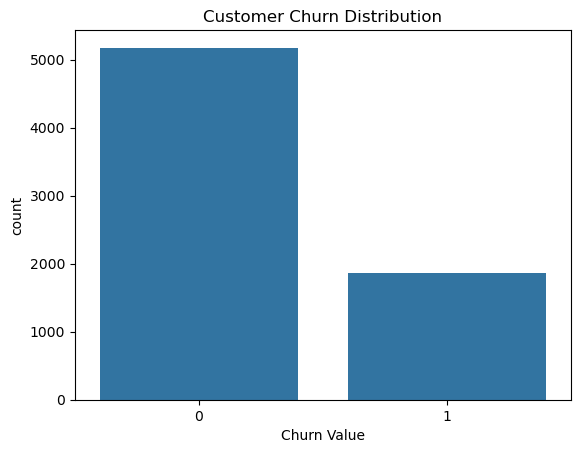

In [17]:
sns.countplot(x='Churn Value', data=df)
plt.title('Customer Churn Distribution')
plt.show()

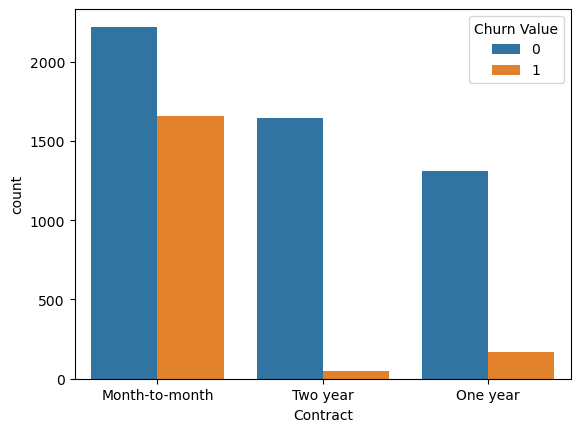

In [18]:
sns.countplot(
    x='Contract',
    hue='Churn Value',
    data=df
)
plt.show()

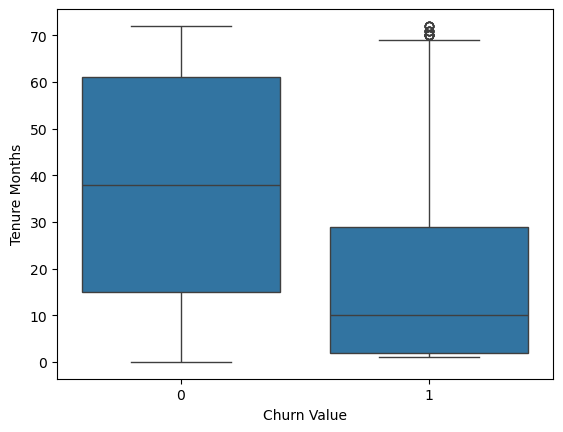

In [19]:
sns.boxplot(
    x='Churn Value',
    y='Tenure Months',
    data=df
)
plt.show()

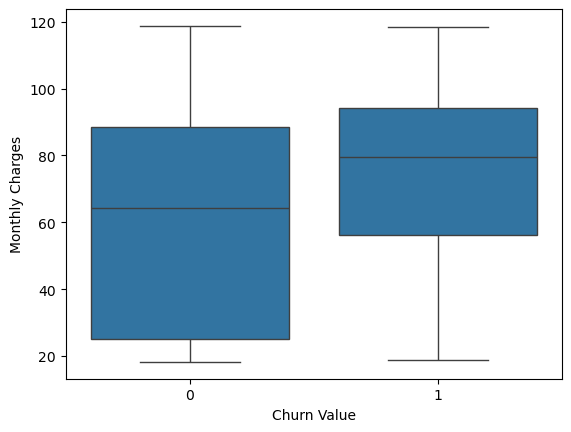

In [20]:
sns.boxplot(
    x='Churn Value',
    y='Monthly Charges',
    data=df
)
plt.show()

8. Feature Engoneering


In [21]:
cols_to_drop = [
    'City',
    'State',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'CLTV'
]

df = df.drop(columns=cols_to_drop)

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [23]:
print(df_encoded.shape)

(7043, 32)


In [24]:
X = df_encoded.drop('Churn Value', axis=1)
y = df_encoded['Churn Value']

print(X.shape)
print(y.shape)

(7043, 31)
(7043,)


In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

Train Test Split

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(5634, 31)
(1409, 31)


In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [28]:
y_pred = lr.predict(X_test_scaled)

In [29]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7998580553584103
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

print(classification_report(y_test, rf_balanced_pred))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_balanced.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                                 Feature  Importance
1                          Tenure Months    0.161565
3                          Total Charges    0.134228
26                     Contract_Two year    0.095468
2                        Monthly Charges    0.092738
7                         Dependents_Yes    0.074767
11          Internet Service_Fiber optic    0.072180
29       Payment Method_Electronic check    0.053966
25                     Contract_One year    0.038861
14                   Online Security_Yes    0.028717
20                      Tech Support_Yes    0.021741
27                 Paperless Billing_Yes    0.018992
13   Online Security_No internet service    0.016273
6                            Partner_Yes    0.015046
16                     Online Backup_Yes    0.013223
23  Streaming Movies_No internet service    0.013056


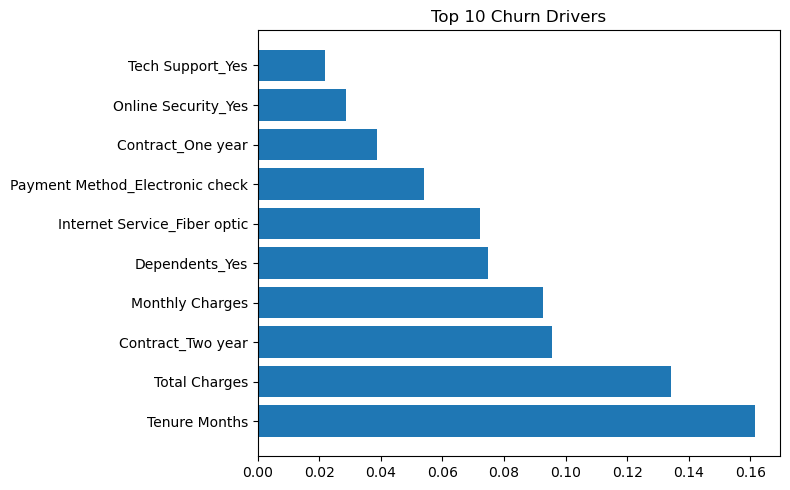

In [32]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.title('Top 10 Churn Drivers')
plt.tight_layout()
plt.show()

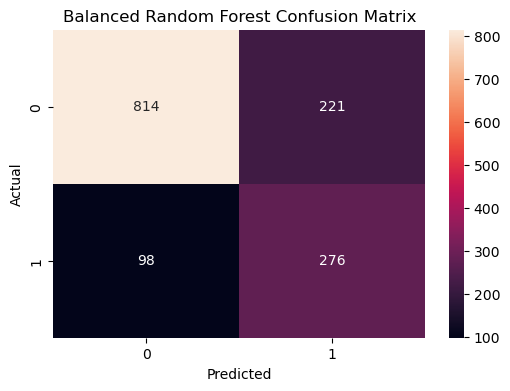

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_balanced_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced Random Forest Confusion Matrix')

plt.show()

In [34]:
from xgboost import XGBClassifier

print("XGBoost installed successfully!")

XGBoost installed successfully!


In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [36]:
import sys
print(sys.executable)

import site
print(site.getsitepackages())

C:\Users\ASUS\anaconda3\python.exe
['C:\\Users\\ASUS\\anaconda3', 'C:\\Users\\ASUS\\anaconda3\\Lib\\site-packages']


In [37]:
import joblib

joblib.dump(rf_balanced, 'churn_model.pkl')

['churn_model.pkl']

In [39]:
import os

os.makedirs('models', exist_ok=True)

In [40]:
import joblib

joblib.dump(rf_balanced, 'models/churn_model.pkl')

['models/churn_model.pkl']

In [41]:
print(os.listdir('models'))

['churn_model.pkl']


In [43]:
df.to_csv("churn_cleaned.csv", index=False)

df_encoded.to_csv("churn_encoded.csv", index=False)

In [44]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'churn_cleaned.csv', 'churn_encoded.csv', 'churn_model.pkl', 'data.csv', 'models', 'Telco_customer_churn.xlsx', 'Untitled.ipynb']
